<a href="https://colab.research.google.com/github/rijuvanak/toxicity_guided_multiobjective_gflownet/blob/main/toxicity_guided_multiobjective_gflownet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PUBLICATION-READY LSTM TOXICITY PREDICTOR
#
# Same project settings:
#   Median toxicity threshold = 3.9
#   1 = Safe
#   0 = Toxic
#   80/20 train-test split
#   Embedding = 128
#   LSTM hidden = 256
#   Batch = 256
#   Epochs = 6
#   Adam lr = 1e-3
#
# Improvements:
#   1. Fixed random seed
#   2. Stratified train/test split
#   3. Correct padding handling
#   4. Uses the actual final SMILES token
#   5. Publication metrics
#   6. Confusion matrix
# ============================================================


# ============================================================
# 1. INSTALL
# ============================================================

!pip -q install scikit-learn tqdm


# ============================================================
# 2. IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from google.colab import files


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make CUDA operations as deterministic as possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 4. DEVICE
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("Random seed:", SEED)


# ============================================================
# 5. PARAMETERS
# ============================================================

BATCH = 256
EPOCHS = 6
EMBED_DIM = 128
HIDDEN_DIM = 256
LEARNING_RATE = 1e-3


# ============================================================
# 6. SMILES VALIDATION
# ============================================================

ALLOWED = set(
    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "abcdefghijklmnopqrstuvwxyz"
    "0123456789"
    "#=[]()+-@./"
)


def valid_smiles(s):

    return (
        isinstance(s, str)
        and 2 <= len(s) <= 150
        and all(c in ALLOWED for c in s)
    )


# ============================================================
# 7. LOAD DATASET
# ============================================================

print("\nUpload toxicity CSV containing:")
print("SMILES")
print("tox_val")

uploaded = files.upload()

tox_file = list(uploaded.keys())[0]

df = pd.read_csv(tox_file)


# ============================================================
# 8. CLEAN DATA
# ============================================================

df = df.dropna(
    subset=[
        "SMILES",
        "tox_val"
    ]
)

df = df[
    df["SMILES"].apply(valid_smiles)
].copy()

print("\nTotal valid molecules:", len(df))


# ============================================================
# 9. CREATE BINARY TOXICITY LABEL
# ============================================================

# Median threshold
threshold = df["tox_val"].median()

print("\nMedian toxicity threshold:", threshold)

# 1 = Safe
# 0 = Toxic

df["label"] = (
    df["tox_val"] <= threshold
).astype(int)


print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass proportions:")
print(df["label"].value_counts(normalize=True))


# ============================================================
# 10. STRATIFIED TRAIN / TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


print("\n==============================")
print("TRAIN / TEST SPLIT")
print("==============================")

print("Training molecules:", len(train_df))
print("Testing molecules :", len(test_df))

print("\nTraining class distribution:")
print(train_df["label"].value_counts())

print("\nTesting class distribution:")
print(test_df["label"].value_counts())


# ============================================================
# 11. BUILD SMILES VOCABULARY
# ============================================================

special_tokens = [
    "<PAD>",
    "<START>",
    "<END>"
]

characters = sorted(
    set(
        "".join(
            train_df["SMILES"]
        )
    )
)

vocab = special_tokens + characters

stoi = {
    c: i
    for i, c in enumerate(vocab)
}

itos = {
    i: c
    for c, i in stoi.items()
}

PAD = 0
START = 1
END = 2

VOCAB_SIZE = len(vocab)

print("\nVocabulary size:", VOCAB_SIZE)


# ============================================================
# 12. ENCODING
# ============================================================

def encode(smiles):

    sequence = [START]

    for c in smiles:

        if c in stoi:
            sequence.append(
                stoi[c]
            )

    sequence.append(END)

    return sequence


# ============================================================
# 13. PADDING
# ============================================================

def pad_sequences(batch):

    lengths = [
        len(x)
        for x in batch
    ]

    max_len = max(lengths)

    arr = np.full(
        (len(batch), max_len),
        PAD,
        dtype=np.int64
    )

    for i, seq in enumerate(batch):

        arr[i, :len(seq)] = seq

    return (
        torch.tensor(
            arr,
            dtype=torch.long
        ).to(DEVICE),

        torch.tensor(
            lengths,
            dtype=torch.long
        ).to(DEVICE)
    )


# ============================================================
# 14. LSTM MODEL
# ============================================================

class ToxicityLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=256
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )


    def forward(
        self,
        x,
        lengths
    ):

        embedded = self.embedding(x)

        # Pack sequences so PAD tokens do not
        # influence the LSTM representation
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (hidden, cell) = self.lstm(
            packed
        )

        # Final hidden state corresponds to
        # the actual sequence, not padding
        final_hidden = hidden[-1]

        return self.fc(
            final_hidden
        )


# ============================================================
# 15. CREATE MODEL
# ============================================================

model = ToxicityLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM
).to(DEVICE)


optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

loss_function = nn.BCEWithLogitsLoss()


print("\nModel:")
print(model)


# ============================================================
# 16. PREPARE TRAINING DATA
# ============================================================

train_sequences = [
    encode(smiles)
    for smiles in train_df["SMILES"]
]

train_labels = (
    train_df["label"]
    .values
    .astype(np.float32)
)


# ============================================================
# 17. TRAIN LSTM
# ============================================================

print("\n======================================")
print("TRAINING TOXICITY LSTM")
print("======================================")

training_losses = []


for epoch in range(EPOCHS):

    model.train()

    total_loss = 0.0

    # Shuffle training data every epoch
    generator = np.random.default_rng(
        SEED + epoch
    )

    order = generator.permutation(
        len(train_sequences)
    )

    for start in range(
        0,
        len(order),
        BATCH
    ):

        batch_idx = order[
            start:start+BATCH
        ]

        batch_sequences = [
            train_sequences[i]
            for i in batch_idx
        ]

        batch_labels = train_labels[
            batch_idx
        ]

        x, lengths = pad_sequences(
            batch_sequences
        )

        y = torch.tensor(
            batch_labels,
            dtype=torch.float32
        ).to(DEVICE)

        output = model(
            x,
            lengths
        ).squeeze(-1)

        loss = loss_function(
            output,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    training_losses.append(
        total_loss
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss: {total_loss:.4f}"
    )


# ============================================================
# 18. PREDICTION FUNCTION
# ============================================================

def predict_safety(smiles_list):

    model.eval()

    sequences = [
        encode(smiles)
        for smiles in smiles_list
    ]

    predictions = []

    with torch.no_grad():

        for start in range(
            0,
            len(sequences),
            BATCH
        ):

            batch_sequences = sequences[
                start:start+BATCH
            ]

            x, lengths = pad_sequences(
                batch_sequences
            )

            logits = model(
                x,
                lengths
            )

            probabilities = torch.sigmoid(
                logits
            )

            predictions.extend(
                probabilities
                .cpu()
                .numpy()
                .flatten()
            )

    return np.array(
        predictions
    )


# ============================================================
# 19. TEST SET PREDICTION
# ============================================================

test_smiles = (
    test_df["SMILES"]
    .tolist()
)

test_labels = (
    test_df["label"]
    .values
)

test_prob = predict_safety(
    test_smiles
)

test_pred = (
    test_prob >= 0.5
).astype(int)


# ============================================================
# 20. PUBLICATION METRICS
# ============================================================

accuracy = accuracy_score(
    test_labels,
    test_pred
)

precision = precision_score(
    test_labels,
    test_pred,
    zero_division=0
)

recall = recall_score(
    test_labels,
    test_pred,
    zero_division=0
)

f1 = f1_score(
    test_labels,
    test_pred,
    zero_division=0
)

auc = roc_auc_score(
    test_labels,
    test_prob
)


# ============================================================
# 21. RESULTS
# ============================================================

print("\n")
print("==============================================")
print("FINAL TOXICITY MODEL TEST RESULTS")
print("==============================================")

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

print(
    f"ROC-AUC  : {auc:.4f}"
)


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    test_pred
)

print("\n==============================================")
print("CONFUSION MATRIX")
print("==============================================")

print(
    "              Predicted"
)

print(
    "              Toxic  Safe"
)

print(
    f"Actual Toxic   {cm[0,0]:5d} {cm[0,1]:5d}"
)

print(
    f"Actual Safe    {cm[1,0]:5d} {cm[1,1]:5d}"
)


# ============================================================
# 23. CLASSIFICATION REPORT
# ============================================================

print("\n==============================================")
print("CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        test_labels,
        test_pred,
        target_names=[
            "Toxic",
            "Safe"
        ],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 24. SAVE TEST PREDICTIONS
# ============================================================

results_df = test_df[
    [
        "SMILES",
        "tox_val",
        "label"
    ]
].copy()

results_df["predicted_safety_probability"] = test_prob

results_df["predicted_label"] = test_pred

results_df["predicted_class"] = results_df[
    "predicted_label"
].map(
    {
        0: "Toxic",
        1: "Safe"
    }
)

results_df.to_csv(
    "toxicity_model_test_predictions.csv",
    index=False
)


# ============================================================
# 25. SAVE MODEL
# ============================================================

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "vocab": vocab,
        "stoi": stoi,
        "threshold": threshold,
        "seed": SEED,
        "embedding_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM
    },
    "toxicity_lstm_publication_model.pt"
)


# ============================================================
# 26. SUMMARY
# ============================================================

print("\n==============================================")
print("EXPERIMENT SUMMARY")
print("==============================================")

print("Dataset size       :", len(df))
print("Training size      :", len(train_df))
print("Test size          :", len(test_df))
print("Toxicity threshold :", threshold)
print("Embedding          :", EMBED_DIM)
print("LSTM hidden size   :", HIDDEN_DIM)
print("Batch size         :", BATCH)
print("Epochs             :", EPOCHS)
print("Learning rate      :", LEARNING_RATE)
print("Random seed        :", SEED)

print("\nTraining losses:")
for i, loss in enumerate(training_losses):
    print(
        f"Epoch {i+1}: {loss:.4f}"
    )

print("\nSaved:")
print("1. toxicity_model_test_predictions.csv")
print("2. toxicity_lstm_publication_model.pt")

print("\n==============================================")
print("TOXICITY MODEL COMPLETE")
print("==============================================")

Device: cpu
Random seed: 42

Upload toxicity CSV containing:
SMILES
tox_val


Saving toxicity_with_smiles.csv to toxicity_with_smiles.csv

Total valid molecules: 51592

Median toxicity threshold: 3.9

Class distribution:
label
1    25851
0    25741
Name: count, dtype: int64

Class proportions:
label
1    0.501066
0    0.498934
Name: proportion, dtype: float64

TRAIN / TEST SPLIT
Training molecules: 41273
Testing molecules : 10319

Training class distribution:
label
1    20680
0    20593
Name: count, dtype: int64

Testing class distribution:
label
1    5171
0    5148
Name: count, dtype: int64

Vocabulary size: 63

Model:
ToxicityLSTM(
  (embedding): Embedding(63, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

TRAINING TOXICITY LSTM
Epoch 1/6 Loss: 105.6311
Epoch 2/6 Loss: 100.4038
Epoch 3/6 Loss: 98.0746
Epoch 4/6 Loss: 96.1339
Epoch 5/6 Loss: 94.6366
Epoch 6/6 Loss: 93.0538


FINAL TOXICITY MODEL TEST RESULTS
Accuracy : 0.6987
Precision: 0.6819
Recall   : 0.7474
F1-score : 0.7132
ROC-A

In [ ]:
predict_safety(["CCO"])

array([0.23287266], dtype=float32)

In [ ]:
!pip install rdkit minisom openpyxl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 12.2 MB/s eta 0:00:00
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=44b7b79c27f4d153763b194efcccdd4329754de045eea2705ac334f673cdbb35
  Stored in directory: /root/.cache/pip/wheels/dc/11/f9/32be492f07fa741d7dcff82007abc966a324da6ab9ceb198e3
Successfully built minisom


In [ ]:
from rdkit import Chem
print("RDKit installed correctly")

RDKit installed correctly


In [ ]:
# =========================================================
# MULTI-OBJECTIVE GFLOWNET PIPELINE
#
# PART 2:
# FDA + NF-kB Chemical Space Reward
#
# Creates:
# 1. FDA similarity score
# 2. NF-kB similarity score
# 3. Combined reward
#
# =========================================================


# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np

from google.colab import files

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem



# =========================================================
# REWARD WEIGHTS
# =========================================================


W_TOX = 0.60
W_FDA = 0.25
W_NFKB = 0.15



print(
    "Reward:"
)

print(
    f"Toxicity  : {W_TOX}"
)

print(
    f"FDA       : {W_FDA}"
)

print(
    f"NF-kB     : {W_NFKB}"
)




# =========================================================
# SMILES COLUMN FINDER
# =========================================================


def find_smiles_column(df):

    for col in df.columns:

        if "SMILES" in col.upper():

            return col


    raise ValueError(
        "No SMILES column found"
    )





# =========================================================
# LOAD FDA MOLECULES
# =========================================================


print(
    "\nUpload FDA approved molecule CSV"
)


upload = files.upload()


fda_file = list(upload.keys())[0]


fda_df = pd.read_csv(
    fda_file,
    encoding="latin1"
)



fda_col = find_smiles_column(
    fda_df
)



fda_smiles = (
    fda_df[fda_col]
    .dropna()
    .astype(str)
    .tolist()
)



print(
    "FDA molecules:",
    len(fda_smiles)
)





# =========================================================
# LOAD NF-kB ACTIVE MOLECULES
# =========================================================


print(
    "\nUpload NF-kB active molecule CSV"
)


upload = files.upload()


nfkb_file = list(upload.keys())[0]


nfkb_df = pd.read_csv(
    nfkb_file,
    encoding="latin1"
)



nfkb_col = find_smiles_column(
    nfkb_df
)



nfkb_smiles = (
    nfkb_df[nfkb_col]
    .dropna()
    .astype(str)
    .tolist()
)



print(
    "NF-kB molecules:",
    len(nfkb_smiles)
)





# =========================================================
# MORGAN FINGERPRINT SETTINGS
# =========================================================


RADIUS = 2

N_BITS = 2048




def smiles_to_fp(smiles):


    mol = Chem.MolFromSmiles(
        smiles
    )


    if mol is None:

        return None



    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    return fp





# =========================================================
# CREATE FDA / NF-kB FINGERPRINT LIBRARIES
# =========================================================


FDA_FPS=[]

for smi in fda_smiles:

    fp = smiles_to_fp(smi)

    if fp is not None:

        FDA_FPS.append(fp)



NFKB_FPS=[]

for smi in nfkb_smiles:

    fp = smiles_to_fp(smi)

    if fp is not None:

        NFKB_FPS.append(fp)




print(
    "\nValid FDA fingerprints:",
    len(FDA_FPS)
)


print(
    "Valid NF-kB fingerprints:",
    len(NFKB_FPS)
)





# =========================================================
# Tanimoto SIMILARITY FUNCTIONS
# =========================================================


def max_similarity_to_library(
        smiles,
        library_fps):


    fp = smiles_to_fp(
        smiles
    )


    if fp is None:

        return 0.0



    similarities=[]


    for ref_fp in library_fps:


        sim = DataStructs.TanimotoSimilarity(
            fp,
            ref_fp
        )


        similarities.append(
            sim
        )



    return max(
        similarities
    )





# =========================================================
# MULTI OBJECTIVE REWARD FUNCTION
# =========================================================


def calculate_reward(smiles):


    # 1. Toxicity reward

    tox_score = predict_safety(
        [smiles]
    )[0]



    # 2. FDA similarity

    fda_score = max_similarity_to_library(
        smiles,
        FDA_FPS
    )



    # 3. NF-kB similarity

    nfkb_score = max_similarity_to_library(
        smiles,
        NFKB_FPS
    )



    # Combined reward

    total_reward = (

        W_TOX * tox_score

        +

        W_FDA * fda_score

        +

        W_NFKB * nfkb_score

    )



    return {

        "toxicity_score": tox_score,

        "FDA_similarity": fda_score,

        "NFkB_similarity": nfkb_score,

        "total_reward": total_reward

    }





# =========================================================
# TEST REWARD FUNCTION
# =========================================================


example = "CCO"


score = calculate_reward(
    example
)


print(
    "\nExample reward:"
)


for k,v in score.items():

    print(
        k,
        ":",
        round(v,4)
    )



print(
    "\nPART 2 COMPLETE"
)

Reward:
Toxicity  : 0.6
FDA       : 0.25
NF-kB     : 0.15

Upload FDA approved molecule CSV


Saving fda_smiles (1).csv to fda_smiles (1).csv
FDA molecules: 3178

Upload NF-kB active molecule CSV


Saving bioassay_with_smiles.csv to bioassay_with_smiles.csv
NF-kB molecules: 3493


Streaming output truncated to the last 5000 lines.
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:03:27] DEPRECATION WARNING: please use MorganGenerator
[17:0


Valid FDA fingerprints: 3178
Valid NF-kB fingerprints: 3493

Example reward:
toxicity_score : 0.2329
FDA_similarity : 0.3571
NFkB_similarity : 0.1282
total_reward : 0.2482

PART 2 COMPLETE


[17:03:30] DEPRECATION WARNING: please use MorganGenerator


Safe training molecules: 20680

Training Multi-objective GFlowNet...


Streaming output truncated to the last 5000 lines.
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:19:44] DEPRECATION WARNING: please use MorganGenerator
[17:1

Epoch 1 Loss: 8539.753


Streaming output truncated to the last 5000 lines.
[17:35:22] DEPRECATION WARNING: please use MorganGenerator
[17:35:22] DEPRECATION WARNING: please use MorganGenerator
[17:35:22] DEPRECATION WARNING: please use MorganGenerator
[17:35:22] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:35:23] DEPRECATION WARNING: please use MorganGenerator
[17:3

Epoch 2 Loss: 6613.509


...

Epoch 3 Loss: 6165.106


Streaming output truncated to the last 5000 lines.
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:07:01] DEPRECATION WARNING: please use MorganGenerator
[18:0

Epoch 4 Loss: 5947.231


Streaming output truncated to the last 5000 lines.
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:23:15] DEPRECATION WARNING: please use MorganGenerator
[18:2

Epoch 5 Loss: 5817.411


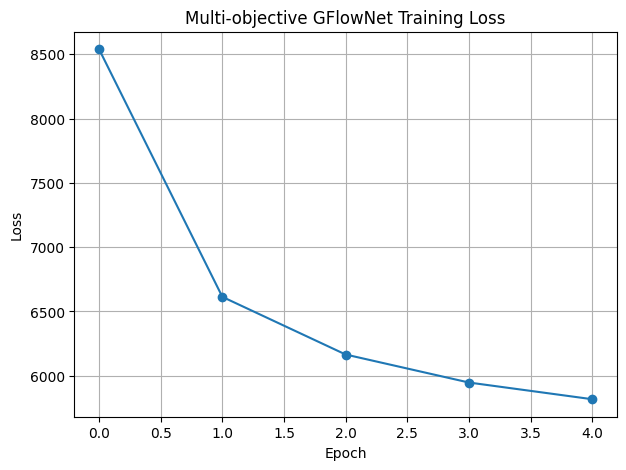


Generating molecules...


100%|██████████| 1000/1000 [00:32<00:00, 30.45it/s]


Generated: 1000
Unique molecules: 573

Scoring generated molecules...


  0%|          | 0/573 [00:00<?, ?it/s][18:25:47] DEPRECATION WARNING: please use MorganGenerator
[18:25:47] DEPRECATION WARNING: please use MorganGenerator
[18:25:47] SMILES Parse Error: syntax error while parsing: O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(
[18:25:47] SMILES Parse Error: check for mistakes around position 53:
[18:25:47] F)C(F)(F)C(F)(F)C(F)(
[18:25:47] ~~~~~~~~~~~~~~~~~~~~^
[18:25:47] SMILES Parse Error: Failed parsing SMILES 'O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(' for input: 'O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)('
[18:25:47] SMILES Parse Error: syntax error while parsing: O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(
[18:25:47] SMILES Parse Error: check for mistakes around position 53:
[18:25:47] F)C(F)(F)C(F)(F)C(F)(
[18:25:47] ~~~~~~~~~~~~~~~~~~~~^
[18:25:47] SMILES Parse Error: Failed parsing SMILES 'O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(' for input: 'O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)


DONE
Saved:
results/generated_multiobjective_ranked.csv
results/top100_generated_candidates.csv


In [ ]:
# =========================================================
# MULTI-OBJECTIVE GFLOWNET PIPELINE
#
# PART 3:
# GFlowNet Training + Generation
#
# Reward:
# 60% Toxicity
# 25% FDA similarity
# 15% NF-kB similarity
#
# =========================================================


import os
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm
import pandas as pd
import numpy as np



# =========================================================
# PREPARE SAFE TRAINING MOLECULES
# =========================================================

# Use low toxicity molecules as starting trajectories

safe_df = train_df[
    train_df.label == 1
]


safe_sequences = [
    encode(s)
    for s in safe_df.SMILES
]


print(
    "Safe training molecules:",
    len(safe_sequences)
)



# =========================================================
# GFLOWNET MODEL
# =========================================================


class GFlowNet(nn.Module):

    def __init__(self):

        super().__init__()


        self.embedding = nn.Embedding(
            VOCAB_SIZE,
            128
        )


        self.lstm = nn.LSTM(
            128,
            256,
            batch_first=True
        )


        self.output = nn.Linear(
            256,
            VOCAB_SIZE
        )



    def forward(self,x):


        x = self.embedding(x)


        out,_ = self.lstm(x)


        logits = self.output(
            out
        )


        return logits





gfn = GFlowNet().to(DEVICE)



optimizer_gfn = optim.Adam(
    gfn.parameters(),
    lr=1e-3
)



# =========================================================
# TRAIN GFLOWNET USING MULTI-OBJECTIVE REWARD
# =========================================================


GFN_EPOCHS = 5



print(
    "\nTraining Multi-objective GFlowNet..."
)



loss_history=[]



for epoch in range(GFN_EPOCHS):


    gfn.train()


    total_loss=0



    for seq in safe_sequences:


        if len(seq)<2:

            continue



        # Convert token sequence back to SMILES

        smi = "".join(
            itos[i]
            for i in seq
            if i > 2
        )



        # ==============================
        # NEW MULTI OBJECTIVE REWARD
        # ==============================

        reward_info = calculate_reward(
            smi
        )


        reward = reward_info[
            "total_reward"
        ]



        x = torch.tensor(
            seq[:-1]
        ).unsqueeze(0).to(DEVICE)



        y = torch.tensor(
            seq[1:]
        ).unsqueeze(0).to(DEVICE)




        logits = gfn(
            x
        )



        log_prob = torch.log_softmax(
            logits,
            dim=-1
        )



        token_logprob = (
            log_prob
            .gather(
                2,
                y.unsqueeze(-1)
            )
            .squeeze(-1)
        )



        loss = (
            -reward *
            token_logprob.mean()
        )



        optimizer_gfn.zero_grad()

        loss.backward()

        optimizer_gfn.step()



        total_loss += loss.item()



    loss_history.append(
        total_loss
    )


    print(
        "Epoch",
        epoch+1,
        "Loss:",
        round(total_loss,3)
    )




# =========================================================
# PLOT GFLOWNET LOSS
# =========================================================


import matplotlib.pyplot as plt



plt.figure(figsize=(7,5))


plt.plot(
    loss_history,
    marker="o"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Multi-objective GFlowNet Training Loss"
)


plt.grid()


plt.savefig(
    "GFN_training_loss.png",
    dpi=300
)


plt.show()





# =========================================================
# MOLECULE GENERATION FUNCTION
# =========================================================


def generate_molecule():


    gfn.eval()


    sequence=[START]



    with torch.no_grad():


        for step in range(100):


            x=torch.tensor(
                sequence
            ).unsqueeze(0).to(DEVICE)



            logits=gfn(x)


            prob=torch.softmax(
                logits[0,-1],
                dim=0
            ).cpu().numpy()



            next_token=np.random.choice(
                len(prob),
                p=prob
            )



            if next_token == END:

                break



            sequence.append(
                next_token
            )




    smiles="".join(
        itos[i]
        for i in sequence
        if i>2
    )



    return smiles





# =========================================================
# GENERATE MOLECULES
# =========================================================


N_GENERATE = 1000



generated=[]



print(
    "\nGenerating molecules..."
)



for i in tqdm(
    range(N_GENERATE)
):


    smi = generate_molecule()



    if valid_smiles(smi):


        generated.append(
            smi
        )




print(
    "Generated:",
    len(generated)
)





# =========================================================
# REMOVE DUPLICATES
# =========================================================


generated = list(
    set(generated)
)



print(
    "Unique molecules:",
    len(generated)
)





# =========================================================
# SCORE GENERATED MOLECULES
# =========================================================


results=[]



print(
    "\nScoring generated molecules..."
)



for smi in tqdm(
    generated
):


    try:


        score = calculate_reward(
            smi
        )


        results.append(
            {

            "SMILES":smi,

            "toxicity_score":
            score["toxicity_score"],

            "FDA_similarity":
            score["FDA_similarity"],

            "NFkB_similarity":
            score["NFkB_similarity"],

            "total_reward":
            score["total_reward"]

            }

        )


    except:

        pass





# =========================================================
# FINAL RANKING
# =========================================================


final_df=pd.DataFrame(
    results
)



final_df = final_df.sort_values(
    "total_reward",
    ascending=False
)



final_df["rank"] = range(
    1,
    len(final_df)+1
)



# =========================================================
# SAVE RESULTS
# =========================================================


os.makedirs(
    "results",
    exist_ok=True
)



final_df.to_csv(
    "results/generated_multiobjective_ranked.csv",
    index=False
)



final_df.head(100).to_csv(
    "results/top100_generated_candidates.csv",
    index=False
)




print(
    "\n================================"
)

print(
    "DONE"
)

print(
    "Saved:"
)

print(
    "results/generated_multiobjective_ranked.csv"
)

print(
    "results/top100_generated_candidates.csv"
)

print(
    "================================"
)

In [ ]:
import shutil
from google.colab import files

# 1. Zip your folder (replace 'my_folder' with your actual folder name)
shutil.make_archive('results', 'zip', 'results')

# 2. Download the zipped file
files.download('results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Total molecules: 200
Valid molecules: 200


[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerator
[19:14:10] DEPRECATION WARNING: please use MorganGenerat

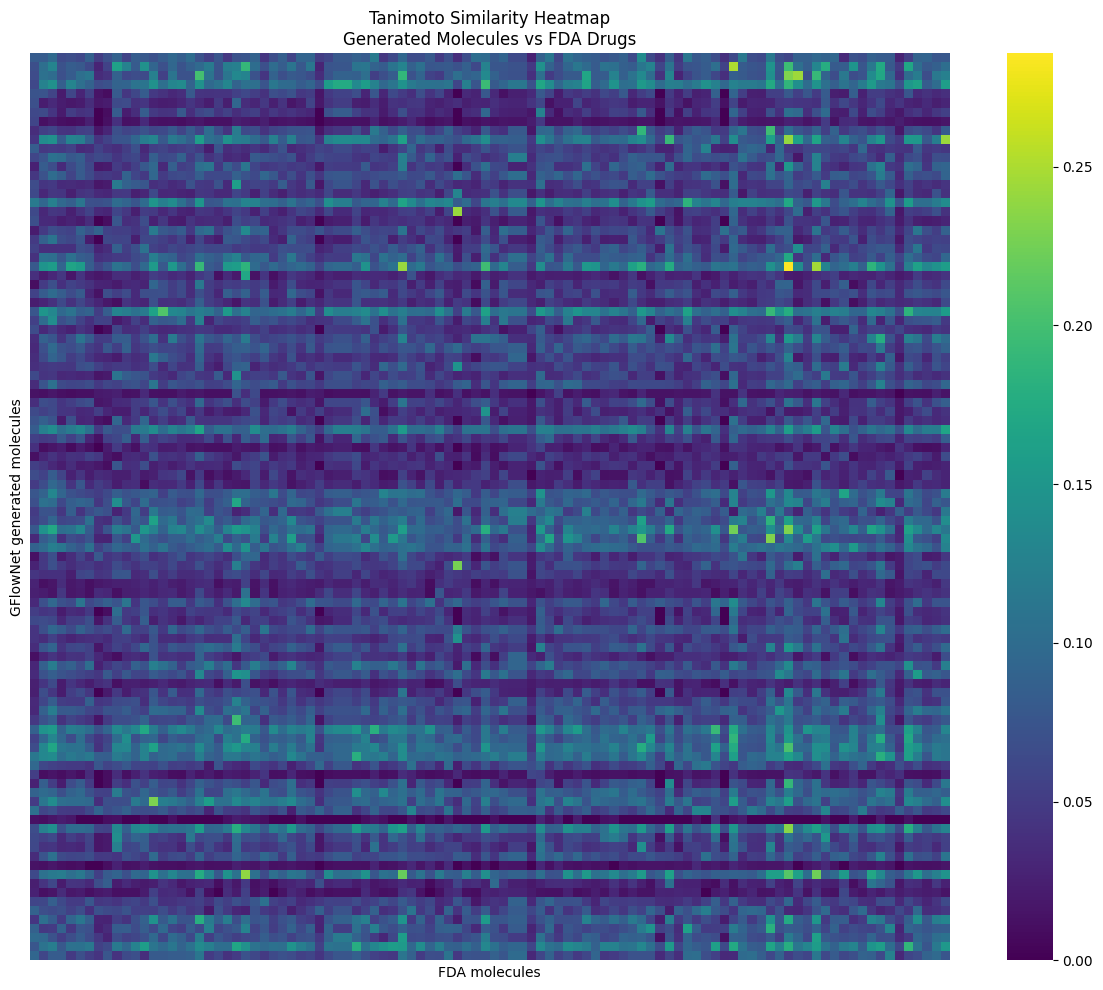

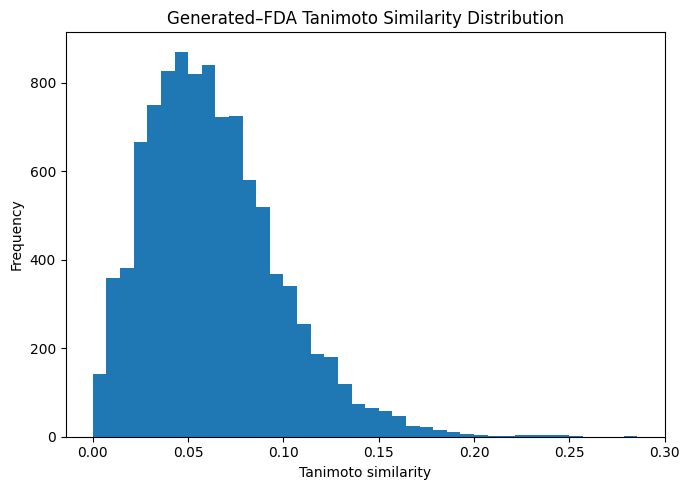

Top similarity pairs saved


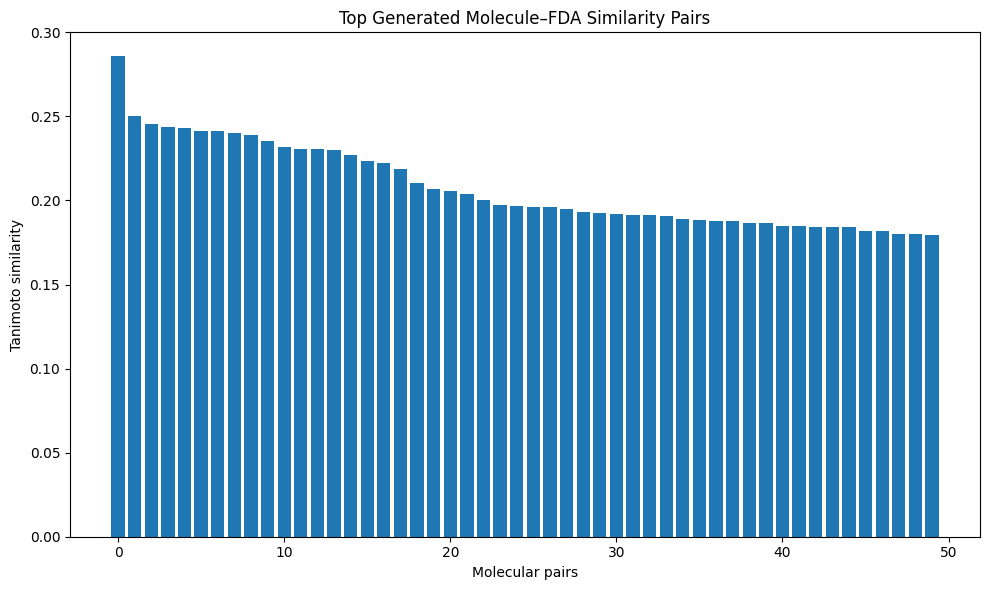

k= 3 Silhouette= 0.04429445823730964
k= 4 Silhouette= 0.040804935725491515
k= 5 Silhouette= 0.039389785120893396
k= 6 Silhouette= 0.044209998720212376
k= 7 Silhouette= 0.060201967043394526
k= 8 Silhouette= 0.06195860105415228
k= 9 Silhouette= 0.0642326011158193
k= 10 Silhouette= 0.06909601291103663


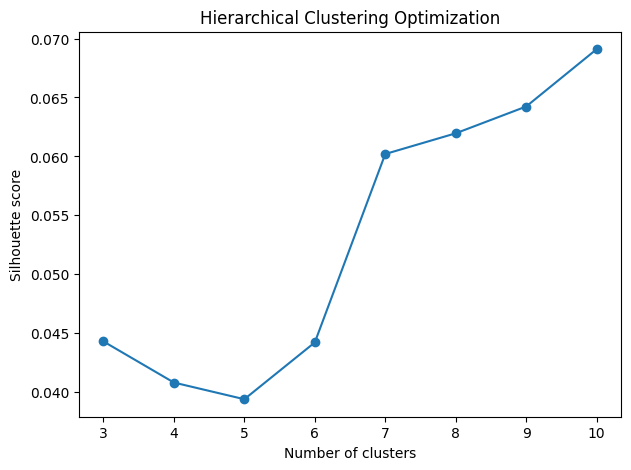

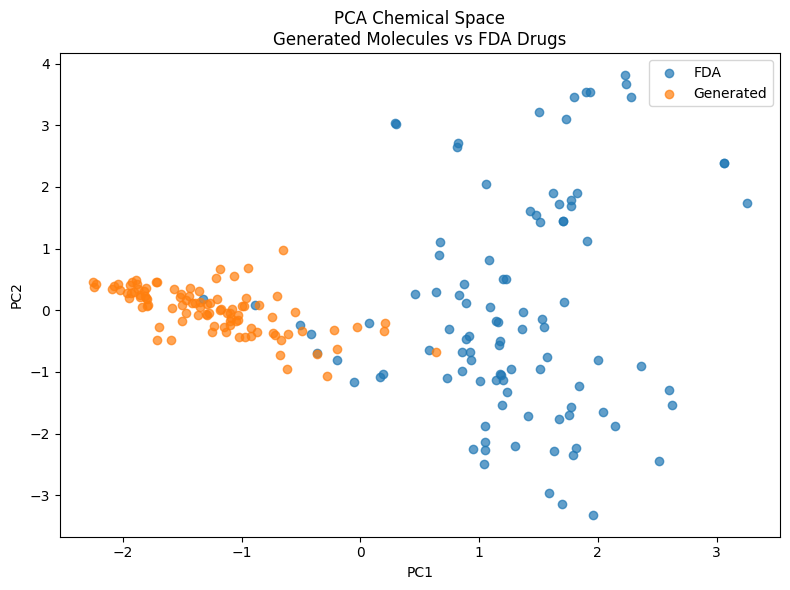

/tmp/ipykernel_1595/2648040522.py:655: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z=linkage(


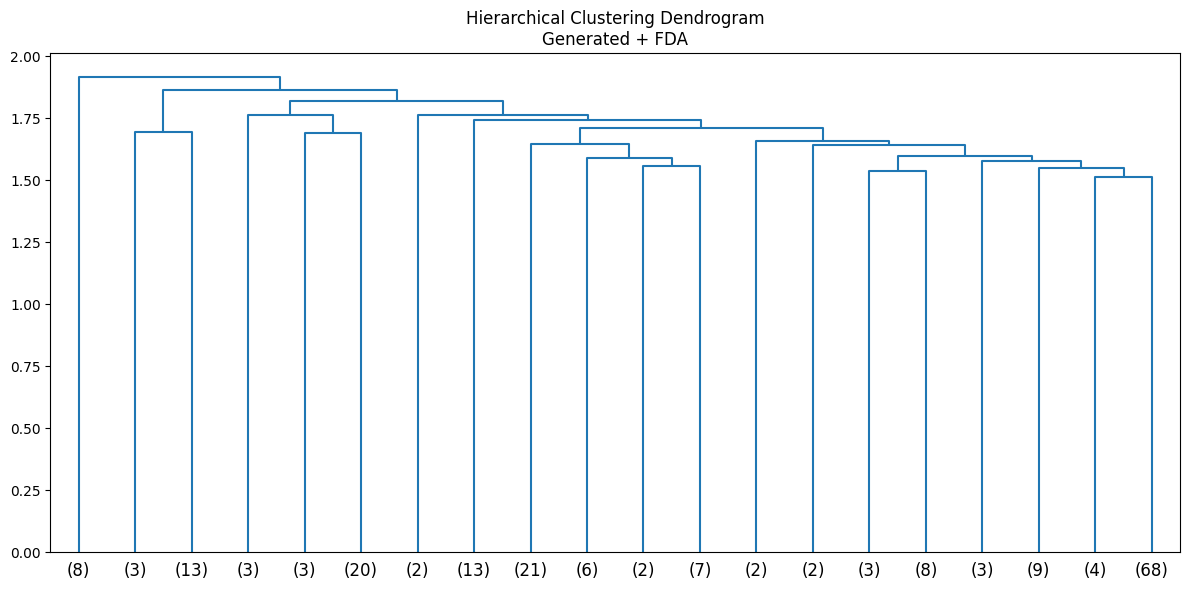


ALL GENERATED-FDA RESULTS SAVED IN: Generated_FDA_results


In [ ]:
# ============================================================
# MOLECULAR CHEMICAL SPACE ANALYSIS
#
# GFlowNet Generated Molecules vs FDA Drugs
#
# Morgan fingerprints
# Tanimoto similarity
# Hierarchical clustering
# PCA visualization
# Heatmap
# Similarity ranking
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage



# ============================================================
# SETTINGS
# ============================================================


GENERATED_FILE = "/content/top100_generated.csv"
FDA_FILE = "/content/TOP100 fda.csv"


SMILES_COL = "SMILES"


N_PER_SET = 100


RADIUS = 2
N_BITS = 2048


MIN_K = 3
MAX_K = 10


TOP_N_PAIRS = 50


OUTPUT_DIR = Path("Generated_FDA_results")
OUTPUT_DIR.mkdir(exist_ok=True)



# ============================================================
# LOAD DATA
# ============================================================


generated = pd.read_csv(
    GENERATED_FILE,
    encoding="latin1"
)


fda = pd.read_csv(
    FDA_FILE,
    encoding="latin1"
)



generated_smiles = (
    generated[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)


fda_smiles = (
    fda[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



all_smiles = generated_smiles + fda_smiles


sources = (
    ["Generated"] * len(generated_smiles)
    +
    ["FDA"] * len(fda_smiles)
)



print("Total molecules:",len(all_smiles))



# ============================================================
# MORGAN FINGERPRINT GENERATION
# ============================================================


def get_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)


    if mol is None:
        return None,None


    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    arr=np.zeros(
        (N_BITS,),
        dtype=int
    )


    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )


    return fp,arr




fps=[]
X=[]
valid_smiles=[]
valid_sources=[]



for smi,src in zip(all_smiles,sources):

    fp,arr=get_fp(smi)


    if fp is not None:

        fps.append(fp)

        X.append(arr)

        valid_smiles.append(smi)

        valid_sources.append(src)



X=np.array(X)



print(
    "Valid molecules:",
    len(X)
)



# ============================================================
# Tanimoto Similarity Matrix
# ============================================================


similarity=np.zeros(
    (len(fps),len(fps))
)



for i in range(len(fps)):

    for j in range(len(fps)):


        similarity[i,j]=DataStructs.TanimotoSimilarity(
            fps[i],
            fps[j]
        )



# ============================================================
# GENERATED vs FDA HEATMAP
# ============================================================


generated_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="Generated"
]


fda_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="FDA"
]



generated_fda_matrix = similarity[
    np.ix_(
        generated_ids,
        fda_ids
    )
]



plt.figure(
    figsize=(12,10)
)



sns.heatmap(
    generated_fda_matrix,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)



plt.xlabel(
    "FDA molecules"
)


plt.ylabel(
    "GFlowNet generated molecules"
)


plt.title(
    "Tanimoto Similarity Heatmap\nGenerated Molecules vs FDA Drugs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_Tanimoto_heatmap.png",
    dpi=300
)



plt.show()




# ============================================================
# SIMILARITY DISTRIBUTION
# ============================================================


values = generated_fda_matrix.flatten()



plt.figure(figsize=(7,5))


plt.hist(
    values,
    bins=40
)



plt.xlabel(
    "Tanimoto similarity"
)


plt.ylabel(
    "Frequency"
)



plt.title(
    "Generated–FDA Tanimoto Similarity Distribution"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_similarity_distribution.png",
    dpi=300
)



plt.show()




# ============================================================
# TOP GENERATED-FDA SIMILARITY PAIRS
# ============================================================


pairs=[]



for i in generated_ids:

    for j in fda_ids:


        sim=similarity[i,j]


        pairs.append(
            (
            sim,
            valid_smiles[i],
            valid_smiles[j]
            )
        )



pairs=sorted(
    pairs,
    reverse=True
)



top_pairs=pairs[:TOP_N_PAIRS]



pd.DataFrame(
    top_pairs,
    columns=[
        "Tanimoto",
        "Generated_SMILES",
        "FDA_SMILES"
    ]

).to_excel(
    OUTPUT_DIR/"Top_Generated_FDA_pairs.xlsx",
    index=False
)



print(
    "Top similarity pairs saved"
)




# ============================================================
# TOP PAIRS BAR GRAPH
# ============================================================



top_df=pd.DataFrame(
    top_pairs,
    columns=[
        "Similarity",
        "Generated",
        "FDA"
    ]
)



plt.figure(
    figsize=(10,6)
)



plt.bar(
    range(len(top_df)),
    top_df["Similarity"]
)



plt.xlabel(
    "Molecular pairs"
)


plt.ylabel(
    "Tanimoto similarity"
)



plt.title(
    "Top Generated Molecule–FDA Similarity Pairs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Top_Generated_FDA_pairs_barplot.png",
    dpi=300
)



plt.show()




# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================


distance = 1 - similarity



silhouette_results=[]



for k in range(MIN_K,MAX_K+1):


    model=AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="average"
    )


    labels=model.fit_predict(distance)



    sil=silhouette_score(
        distance,
        labels,
        metric="precomputed"
    )



    print(
        "k=",
        k,
        "Silhouette=",
        sil
    )


    silhouette_results.append(
        [k,sil]
    )



    cluster_df=pd.DataFrame(
        {
        "SMILES":valid_smiles,
        "Source":valid_sources,
        "Cluster":labels
        }
    )



    cluster_df.to_excel(
        OUTPUT_DIR/f"Generated_FDA_clusters_k{k}.xlsx",
        index=False
    )



# ============================================================
# SILHOUETTE CURVE
# ============================================================


sil_df=pd.DataFrame(
    silhouette_results,
    columns=[
        "k",
        "Silhouette"
    ]
)



plt.figure(figsize=(7,5))


plt.plot(
    sil_df["k"],
    sil_df["Silhouette"],
    marker="o"
)



plt.xlabel(
    "Number of clusters"
)


plt.ylabel(
    "Silhouette score"
)



plt.title(
    "Hierarchical Clustering Optimization"
)



plt.savefig(
    OUTPUT_DIR/"silhouette_curve.png",
    dpi=300
)



plt.show()




# ============================================================
# PCA CHEMICAL SPACE
# ============================================================



pca=PCA(
    n_components=2
)



coords=pca.fit_transform(X)




plt.figure(figsize=(8,6))



for src in set(valid_sources):


    idx=[
        i for i,s in enumerate(valid_sources)
        if s==src
    ]


    plt.scatter(
        coords[idx,0],
        coords[idx,1],
        label=src,
        alpha=0.7
    )



plt.xlabel("PC1")

plt.ylabel("PC2")


plt.title(
    "PCA Chemical Space\nGenerated Molecules vs FDA Drugs"
)


plt.legend()



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"PCA_Generated_FDA.png",
    dpi=300
)



plt.show()




# ============================================================
# DENDROGRAM
# ============================================================



Z=linkage(
    distance,
    method="average"
)



plt.figure(
    figsize=(12,6)
)



dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)



plt.title(
    "Hierarchical Clustering Dendrogram\nGenerated + FDA"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_FDA_dendrogram.png",
    dpi=300
)



plt.show()



print(
    "\nALL GENERATED-FDA RESULTS SAVED IN:",
    OUTPUT_DIR
)

In [ ]:
import shutil
from google.colab import files

# 1. Zip your folder (replace 'my_folder' with your actual folder name)
shutil.make_archive('Generated_FDA_results', 'zip', 'Generated_FDA_results')

# 2. Download the zipped file
files.download('Generated_FDA_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Total molecules: 200
Valid molecules: 200


[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerator
[19:22:26] DEPRECATION WARNING: please use MorganGenerat

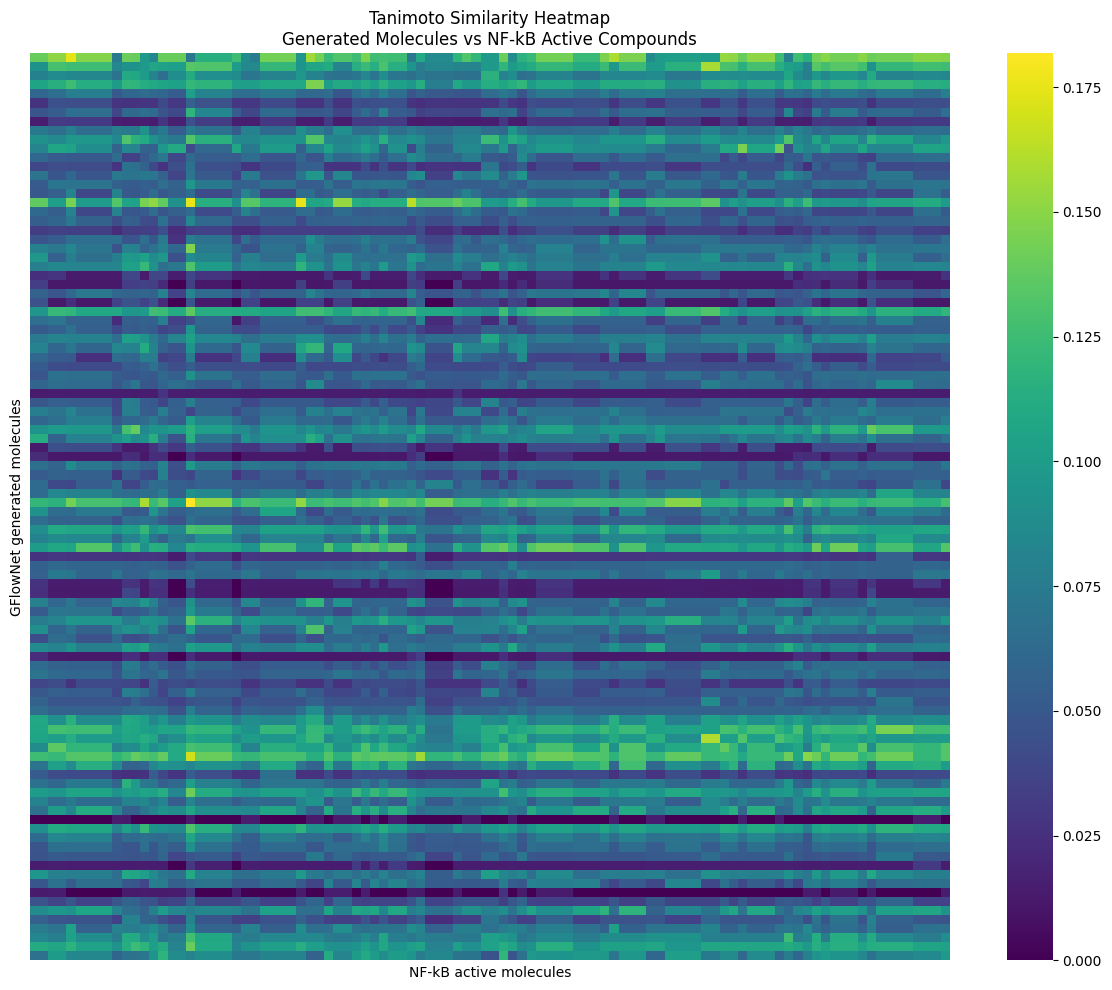

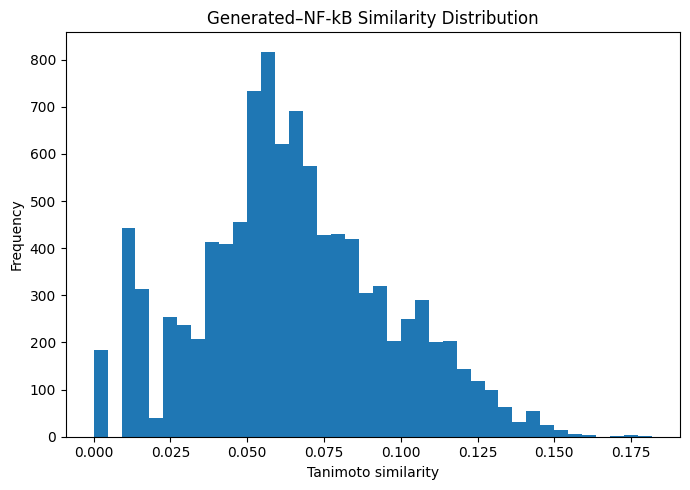

Top Generated-NFkB pairs saved


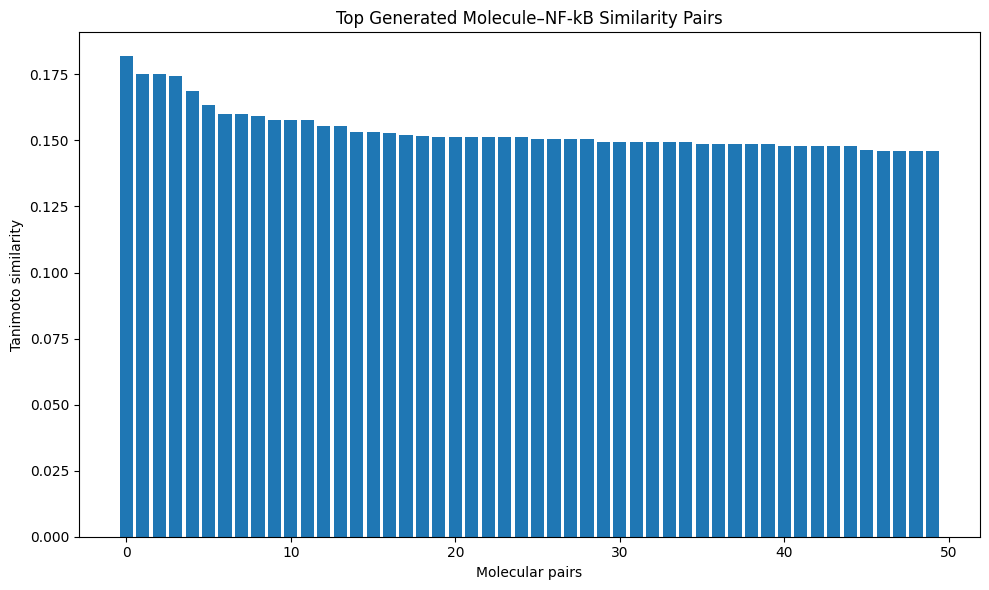

k= 3 Silhouette= 0.1258959281156726
k= 4 Silhouette= 0.1342546462896589
k= 5 Silhouette= 0.13719773958957732
k= 6 Silhouette= 0.14313942988767422
k= 7 Silhouette= 0.1948561215813789
k= 8 Silhouette= 0.19716181336753788
k= 9 Silhouette= 0.2049599521363314
k= 10 Silhouette= 0.2105769572232132


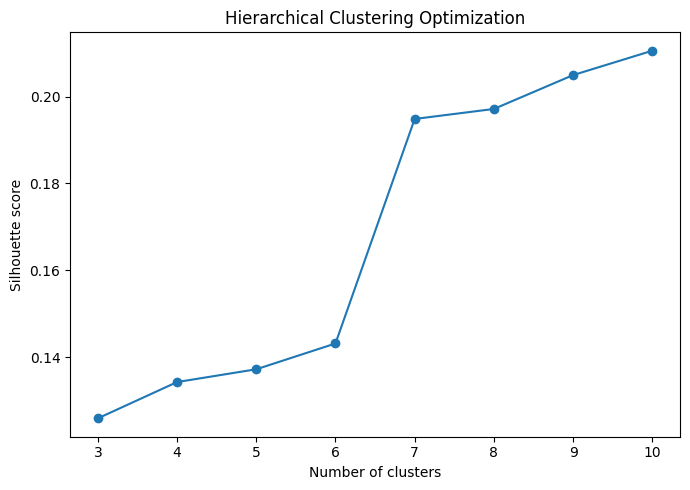

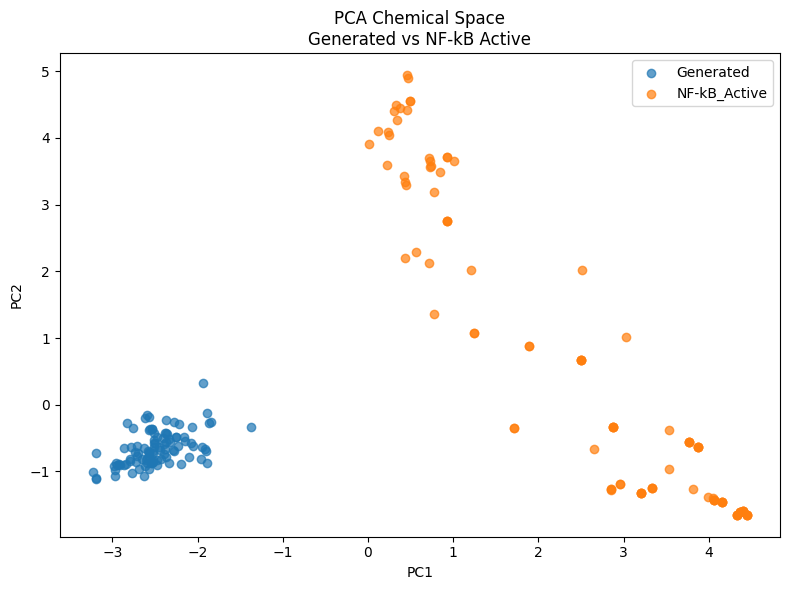

/tmp/ipykernel_1595/2664213238.py:677: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z=linkage(


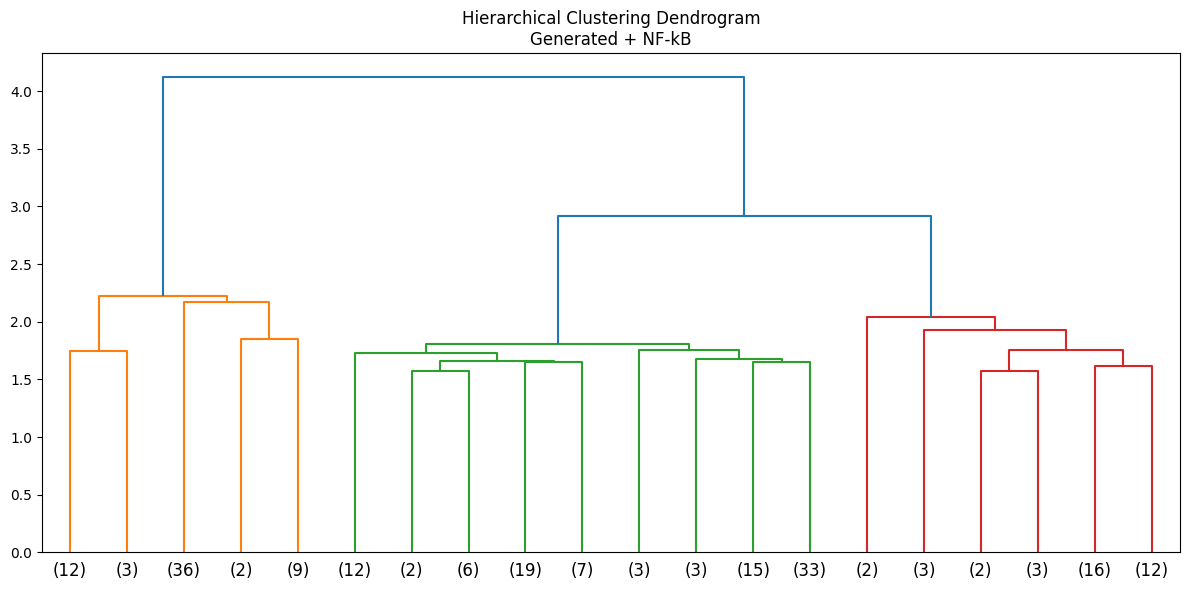


ALL Generated-NFkB RESULTS SAVED IN: Generated_NFkB_results


In [ ]:


# ============================================================
# MOLECULAR CHEMICAL SPACE ANALYSIS
#
# GFlowNet Generated Molecules vs NF-kB Active Molecules
#
# Morgan fingerprints
# Tanimoto similarity
# Hierarchical clustering
# PCA visualization
# Similarity heatmap
# Similarity ranking
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage



# ============================================================
# SETTINGS
# ============================================================


GENERATED_FILE = "/content/top100_generated.csv"

NFKB_FILE = "/content/top 100 actives.csv"


SMILES_COL = "SMILES"


N_PER_SET = 100


RADIUS = 2
N_BITS = 2048


MIN_K = 3
MAX_K = 10


TOP_N_PAIRS = 50


OUTPUT_DIR = Path("Generated_NFkB_results")

OUTPUT_DIR.mkdir(exist_ok=True)



# ============================================================
# LOAD DATA
# ============================================================


generated = pd.read_csv(
    GENERATED_FILE,
    encoding="latin1"
)


nfkb = pd.read_csv(
    NFKB_FILE,
    encoding="latin1"
)



generated_smiles = (
    generated[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



nfkb_smiles = (
    nfkb[SMILES_COL]
    .head(N_PER_SET)
    .astype(str)
    .tolist()
)



all_smiles = (
    generated_smiles
    +
    nfkb_smiles
)



sources = (
    ["Generated"] * len(generated_smiles)
    +
    ["NF-kB_Active"] * len(nfkb_smiles)
)



print(
    "Total molecules:",
    len(all_smiles)
)




# ============================================================
# MORGAN FINGERPRINT
# ============================================================


def get_fp(smiles):

    mol = Chem.MolFromSmiles(smiles)


    if mol is None:
        return None,None


    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        RADIUS,
        N_BITS
    )


    arr=np.zeros(
        (N_BITS,),
        dtype=int
    )


    DataStructs.ConvertToNumpyArray(
        fp,
        arr
    )


    return fp,arr




fps=[]
X=[]

valid_smiles=[]
valid_sources=[]



for smi,src in zip(all_smiles,sources):


    fp,arr=get_fp(smi)


    if fp is not None:


        fps.append(fp)

        X.append(arr)

        valid_smiles.append(smi)

        valid_sources.append(src)




X=np.array(X)



print(
    "Valid molecules:",
    len(X)
)




# ============================================================
# TANIMOTO SIMILARITY MATRIX
# ============================================================


similarity=np.zeros(
    (len(fps),len(fps))
)



for i in range(len(fps)):

    for j in range(len(fps)):


        similarity[i,j]=DataStructs.TanimotoSimilarity(
            fps[i],
            fps[j]
        )




# ============================================================
# GENERATED vs NF-kB HEATMAP
# ============================================================


generated_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="Generated"
]


nfkb_ids=[
    i for i,s in enumerate(valid_sources)
    if s=="NF-kB_Active"
]



generated_nfkb_matrix = similarity[
    np.ix_(
        generated_ids,
        nfkb_ids
    )
]




plt.figure(
    figsize=(12,10)
)



sns.heatmap(
    generated_nfkb_matrix,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)



plt.xlabel(
    "NF-kB active molecules"
)



plt.ylabel(
    "GFlowNet generated molecules"
)



plt.title(
    "Tanimoto Similarity Heatmap\nGenerated Molecules vs NF-kB Active Compounds"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_Tanimoto_heatmap.png",
    dpi=300
)



plt.show()




# ============================================================
# SIMILARITY DISTRIBUTION
# ============================================================


values = generated_nfkb_matrix.flatten()



plt.figure(figsize=(7,5))


plt.hist(
    values,
    bins=40
)



plt.xlabel(
    "Tanimoto similarity"
)



plt.ylabel(
    "Frequency"
)



plt.title(
    "Generated–NF-kB Similarity Distribution"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_similarity_distribution.png",
    dpi=300
)



plt.show()




# ============================================================
# TOP GENERATED-NFkB PAIRS
# ============================================================


pairs=[]



for i in generated_ids:

    for j in nfkb_ids:


        sim=similarity[i,j]


        pairs.append(
            (
            sim,
            valid_smiles[i],
            valid_smiles[j]
            )
        )



pairs=sorted(
    pairs,
    reverse=True
)



top_pairs=pairs[:TOP_N_PAIRS]



pd.DataFrame(
    top_pairs,
    columns=[
        "Tanimoto",
        "Generated_SMILES",
        "NFkB_SMILES"
    ]

).to_excel(
    OUTPUT_DIR/"Top_Generated_NFkB_pairs.xlsx",
    index=False
)



print(
    "Top Generated-NFkB pairs saved"
)




# ============================================================
# TOP PAIR BAR PLOT
# ============================================================


top_df=pd.DataFrame(
    top_pairs,
    columns=[
        "Similarity",
        "Generated",
        "NFkB"
    ]
)



plt.figure(figsize=(10,6))



plt.bar(
    range(len(top_df)),
    top_df["Similarity"]
)



plt.xlabel(
    "Molecular pairs"
)



plt.ylabel(
    "Tanimoto similarity"
)



plt.title(
    "Top Generated Molecule–NF-kB Similarity Pairs"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Top_Generated_NFkB_pairs_barplot.png",
    dpi=300
)



plt.show()




# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================


distance = 1 - similarity



silhouette_results=[]



for k in range(MIN_K,MAX_K+1):


    model=AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="average"
    )



    labels=model.fit_predict(distance)



    sil=silhouette_score(
        distance,
        labels,
        metric="precomputed"
    )



    print(
        "k=",
        k,
        "Silhouette=",
        sil
    )


    silhouette_results.append(
        [k,sil]
    )



    pd.DataFrame(
        {
        "SMILES":valid_smiles,
        "Source":valid_sources,
        "Cluster":labels
        }
    ).to_excel(
        OUTPUT_DIR/f"Generated_NFkB_clusters_k{k}.xlsx",
        index=False
    )




# ============================================================
# SILHOUETTE CURVE
# ============================================================


sil_df=pd.DataFrame(
    silhouette_results,
    columns=[
        "k",
        "Silhouette"
    ]
)



plt.figure(figsize=(7,5))


plt.plot(
    sil_df["k"],
    sil_df["Silhouette"],
    marker="o"
)



plt.xlabel(
    "Number of clusters"
)


plt.ylabel(
    "Silhouette score"
)



plt.title(
    "Hierarchical Clustering Optimization"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"silhouette_curve.png",
    dpi=300
)



plt.show()




# ============================================================
# PCA CHEMICAL SPACE
# ============================================================


pca=PCA(
    n_components=2
)



coords=pca.fit_transform(X)




plt.figure(figsize=(8,6))



for src in set(valid_sources):


    idx=[
        i for i,s in enumerate(valid_sources)
        if s==src
    ]


    plt.scatter(
        coords[idx,0],
        coords[idx,1],
        label=src,
        alpha=0.7
    )



plt.xlabel("PC1")

plt.ylabel("PC2")



plt.title(
    "PCA Chemical Space\nGenerated vs NF-kB Active"
)



plt.legend()



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"PCA_Generated_NFkB.png",
    dpi=300
)



plt.show()




# ============================================================
# DENDROGRAM
# ============================================================


Z=linkage(
    distance,
    method="average"
)



plt.figure(
    figsize=(12,6)
)



dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)



plt.title(
    "Hierarchical Clustering Dendrogram\nGenerated + NF-kB"
)



plt.tight_layout()



plt.savefig(
    OUTPUT_DIR/"Generated_NFkB_dendrogram.png",
    dpi=300
)



plt.show()



print(
    "\nALL Generated-NFkB RESULTS SAVED IN:",
    OUTPUT_DIR
)

In [ ]:
import shutil
from google.colab import files

# 1. Zip your folder (replace 'my_folder' with your actual folder name)
shutil.make_archive('Generated_NFkB_results', 'zip', 'Generated_NFkB_results')

# 2. Download the zipped file
files.download('Generated_NFkB_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')